<a href="https://colab.research.google.com/github/sournorm/-_3-8_-_-/blob/main/%D0%9B%D0%A02_%D0%97%D0%B0%D0%BF%D0%BE%D1%80%D0%BE%D0%B6%D0%B0%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Запорожан Сергій ФІТ 3-8
ФІТ 3-8, КСВД ЛР-2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Global_YouTube_Statistics[1].csv to Global_YouTube_Statistics[1].csv


# YouTube Statistics 2023

--- Перші 5 рядків YouTube ---


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


Розміри датасету: (995, 28)

Кількість пропусків по стовпцях:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 

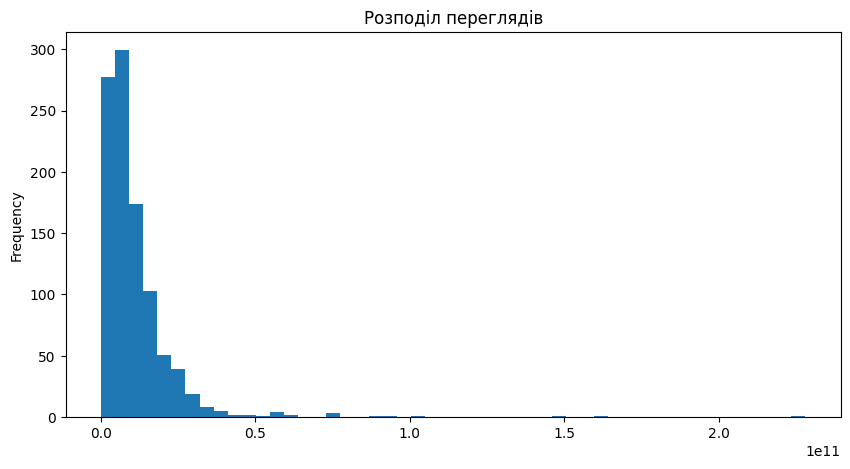

Макс переглядів: 228000000000.0
Країна-лідер за uploads: India
Канал з макс завантаженнями: ABP NEWS


In [24]:
df_yt = pd.read_csv('/content/Global_YouTube_Statistics[1].csv', encoding='latin-1')

# 2-3. Вивід даних
print("--- Перші 5 рядків YouTube ---")
display(df_yt.head())
print(f"Розміри датасету: {df_yt.shape}")

# 4-6. Обробка пропусків
print("\nКількість пропусків по стовпцях:")
print(df_yt.isna().sum())

# Заміна пустих на NaN та заповнення середнім
df_yt.replace(['NaN', 'nan', '', ' '], np.nan, inplace=True)
numeric_cols = df_yt.select_dtypes(include=[np.number]).columns
df_yt[numeric_cols] = df_yt[numeric_cols].astype(float)
df_yt[numeric_cols] = df_yt[numeric_cols].fillna(df_yt[numeric_cols].mean())

# 7-8. Унікальні країни та діаграма
print(f"\nУнікальних країн: {df_yt['Country'].nunique()}")
df_yt['video views'].plot(kind='hist', bins=50, title='Розподіл переглядів', figsize=(10,5))
plt.show()

# 9-11. Статистика та лідери
print(f"Макс переглядів: {df_yt['video views'].max()}")
print(f"Країна-лідер за uploads: {df_yt.groupby('Country')['uploads'].sum().idxmax()}")
print(f"Канал з макс завантаженнями: {df_yt.loc[df_yt['uploads'].idxmax(), 'Youtuber']}")

# **Amazon Top 50 Bestselling Books**


In [25]:
df_books = pd.read_csv('/content/bestsellers with categories.csv')
print("\n--- Перші 10 рядків книг ---")
display(df_books.head(10))
print(f"Кількість книг: {df_books.shape[0]}")

# 4. Зміна назв колонок
df_books.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

# 5-7. Пропуски та статистика
print(f"\nЧи є пропуски? {'Так' if df_books.isna().any().any() else 'Ні'}")
print(f"Жанри: {df_books['genre'].unique()}")
print(f"Ціни: Макс={df_books['price'].max()}, Мін={df_books['price'].min()}, Медіана={df_books['price'].median()}")

# 8. Пошук і сортування
max_rating = df_books['user_rating'].max()
print(f"\nНайвищий рейтинг: {max_rating}")
print(f"Книга з макс відгуків: {df_books.loc[df_books['reviews'].idxmax(), 'name']}")
print(f"Найдорожча книга 2010: {df_books[df_books['year']==2010].sort_values('price').iloc[-1]['name']}")

# Группування за жанрами
print("\nМакс/Мін ціна за жанрами:")
print(df_books.groupby('genre')['price'].agg(['max', 'min']))


--- Перші 10 рядків книг ---


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


Кількість книг: 550

Чи є пропуски? Ні
Жанри: ['Non Fiction' 'Fiction']
Ціни: Макс=105, Мін=0, Медіана=11.0

Найвищий рейтинг: 4.9
Книга з макс відгуків: Where the Crawdads Sing
Найдорожча книга 2010: Publication Manual of the American Psychological Association, 6th Edition

Макс/Мін ціна за жанрами:
             max  min
genre                
Fiction       82    0
Non Fiction  105    0
